# **Building the full hourly dataset (2022 -> 2026)**

We want a single, continuous **hourly** day-ahead price series for Spain that our models can learn from.

Reading the ENTSO-E API docs, it can be observed that you can only get data in **one-year** range for day ahead prices. This will be a problem, as we want our models to learn from all historic data. As a result, we will have to join several bits of data.

To build it we join two "eras":

- 2022-09-30 -> 2025-09-30 - the market cleared hourly (`PT60M`). We pull this in 3 calls (the API only allows ~1 year each).
- 2025-10-01 -> 2026-08-14 - the market cleared every 15 minutes (`PT15M`) after the Oct-1-2025 change. We pull this in 1 call and average each hour's 4 quarters to stay hourly.

Three things we learned about this data to keep them in mind:

1. The same response also carries the intraday auctions (`A07`, IDA1/2/3). We ask for `contract_MarketAgreement.Type = A01` in the URL and re-check it when parsing.
2. ENTSO-E omits a point whenever the price repeats (`curveType A03`). A "missing" position is not missing data, it equals the previous one. We rebuild the full grid and `ffill()`.
3. Our calls touch at the edges, we let them overlap and drop duplicate timestamps, instead of shaving days by hand (which risks creating holes).


---

## **01 - Imports & Configuration**

In [1]:
import os
import requests
import pandas as pd
import xml.etree.ElementTree as ET
from dotenv import load_dotenv

# --- API key ---
# Loaded from .env (git-ignored)
load_dotenv()
API_KEY = os.getenv("ENTSOE_API_KEY")

if not API_KEY:
    raise ValueError("Missing ENTSOE_API_KEY. Copy .env.example to .env and add your token.")

# Spain bidding zone (day-ahead). Same EIC for in_Domain and out_Domain.
DOMAIN   = "10YES-REE------0"
BASE_URL = "https://web-api.tp.entsoe.eu/api"

---

## **02 - The Hourly Era**

From 2022-09-30 to 2025-09-30



### **Block 1 - download the 3 years**

We store the 3 raw XML answers in a list so the next block can parse them together.

Note the ranges *touch* at the edges (each year's end = next year's start). That's intentional, we remove duplicate timestamps later instead of subtracting days by hand.

In [3]:
# ENTSO-E allows ~1 year per call, so we split 3 years into 3 calls.
# We ask ONLY for day-ahead (contract_MarketAgreement.Type = A01), so the
# server leaves out the intraday auctions (which are A07).

phase1_ranges = [
    ("202209302200", "202309302200"),   # year 1
    ("202309302200", "202409302200"),   # year 2
    ("202409302200", "202509302200"),   # year 3
]

xml_responses_phase1 = []   # we collect the 3 raw XML strings here

for period_start, period_end in phase1_ranges:
    params = {
        "documentType": "A44",                    # A44 = price document
        "in_Domain":  DOMAIN,
        "out_Domain": DOMAIN,
        "contract_MarketAgreement.Type": "A01",   # A01 = day-ahead only
        "periodStart": period_start,
        "periodEnd":   period_end,
        "securityToken": API_KEY,
    }
    response = requests.get(BASE_URL, params=params)
    print(f"{period_start} -> {period_end} : HTTP {response.status_code}")
    xml_responses_phase1.append(response.text)

    # Optional: keep an untouched copy of the raw download (data/raw philosophy).
    with open(f"raw_dayahead_{period_start}_{period_end}.xml", "w", encoding="utf-8") as f:
        f.write(response.text)

202209302200 -> 202309302200 : HTTP 200
202309302200 -> 202409302200 : HTTP 200
202409302200 -> 202509302200 : HTTP 200


### **Block 2 - XML to raw DataFrame**

We walk every response and pull **one row per `<Point>`**: which market it is, the period start, the resolution, the position number, and the price. We do **not** compute the timestamp yet — that's the next block.

In [4]:
rows = []

for xml_text in xml_responses_phase1:
    root = ET.fromstring(xml_text)

    # The namespace version can change between calls, so read it from the root
    # tag instead of hard-coding it. root.tag looks like
    #   "{urn:iec62325.351:tc57wg16:451-3:publicationdocument:7:3}Publication_MarketDocument"
    ns = {"ns": root.tag.split("}")[0].strip("{")}

    for ts in root.findall("ns:TimeSeries", ns):
        # A01 = day-ahead, A07 = intraday. If the tag is missing, ENTSO-E means A01.
        contract = ts.findtext("ns:contract_MarketAgreement.type", default="A01", namespaces=ns)

        for period in ts.findall("ns:Period", ns):
            p_start    = period.findtext("ns:timeInterval/ns:start", namespaces=ns)
            resolution = period.findtext("ns:resolution", namespaces=ns)

            for point in period.findall("ns:Point", ns):
                position = int(point.findtext("ns:position", namespaces=ns))
                price    = float(point.findtext("ns:price.amount", namespaces=ns))
                rows.append({
                    "contract_type": contract,
                    "period_start":  p_start,
                    "resolution":    resolution,
                    "position":      position,
                    "price_eur_mwh": price,
                })

df_raw_phase1 = pd.DataFrame(rows)
print(df_raw_phase1.shape)
df_raw_phase1.tail()

(24391, 5)


,contract_type,period_start,resolution,position,price_eur_mwh
24386,A01,2025-09-29T22:00Z,PT60M,20,117.00
24387,A01,2025-09-29T22:00Z,PT60M,21,199.34
24388,A01,2025-09-29T22:00Z,PT60M,22,172.11
24389,A01,2025-09-29T22:00Z,PT60M,23,119.90
24390,A01,2025-09-29T22:00Z,PT60M,24,101.50


### **Block 3 - raw DataFrame to the df we want (`datetime` + `price_eur_mwh`)**

Five steps:
1. keep day-ahead only (safety net - the URL already filtered `A01`),
2. turn `PT60M`/`PT15M` into a real time step,
3. build each point's real timestamp: `start + (position − 1) × step`,
4. sort by datetime and drop duplicate timestamps (the overlap),
5. **A03 fix**, rebuild a complete hourly grid and forward-fill the points ENTSO-E omitted.


In [5]:
df = df_raw_phase1.copy()

# 1. day-ahead only
df = df[df["contract_type"] == "A01"]

# 2. resolution -> timedelta
step = {"PT60M": pd.Timedelta(hours=1), "PT15M": pd.Timedelta(minutes=15)}
df["step"] = df["resolution"].map(step)

# 3. real timestamp (period_start is UTC, e.g. 2024-09-30T22:00Z)
df["period_start"] = pd.to_datetime(df["period_start"])
df["datetime"] = df["period_start"] + (df["position"] - 1) * df["step"]

# 4. clean series: datetime index, sorted, no duplicate timestamps
s = df.set_index("datetime")["price_eur_mwh"].sort_index()
s = s[~s.index.duplicated(keep="first")]

# 5. A03 forward-fill on a complete hourly grid
before = len(s)
s = s.asfreq("h").ffill()
print(f"A03 fill: {len(s) - before} hours were missing and got forward-filled")
# (a small number = normal A03 compression; a big number = investigate a real gap)

df_hourly_2022_2025 = s.to_frame()
print(df_hourly_2022_2025.shape)
df_hourly_2022_2025.tail()

A03 fill: 1913 hours were missing and got forward-filled
(26304, 1)


,price_eur_mwh
datetime,
2025-09-30 17:00:00+00:00,117.00
2025-09-30 18:00:00+00:00,199.34
2025-09-30 19:00:00+00:00,172.11
2025-09-30 20:00:00+00:00,119.90
2025-09-30 21:00:00+00:00,101.50


---
## **03 - The 15-Minute Era**

From 2025-10-01 to 2026-08-14



### **Block 1 - download the recent range (single call)**

Less than a year, so one call. Same `A01` day-ahead filter. The data comes back at 15-minute resolution because of the Oct-1-2025 market change.

In [6]:
params = {
    "documentType": "A44",
    "in_Domain":  DOMAIN,
    "out_Domain": DOMAIN,
    "contract_MarketAgreement.Type": "A01",
    "periodStart": "202509302200",   # 2025-10-01 00:00 local = first 15-min day-ahead point
    "periodEnd":   "202608142200",   # up to 2026-08-14
    "securityToken": API_KEY,
}

# periodEnd FIXED on purpose: we freeze the dataset at a cutoff date
# so that training and evaluation are reproducible and models
# comparable to each other. Live updates (periodEnd = yesterday) belong
# to the deployment phase, not the modeling phase.

response = requests.get(BASE_URL, params=params)
print("HTTP", response.status_code)

# keep it in a list so we can reuse the exact same parsing loop as Phase 1
xml_responses_phase2 = [response.text]

with open("raw_dayahead_15min_2025_2026.xml", "w", encoding="utf-8") as f:
    f.write(response.text)

HTTP 200


###  **Block 2 - XML to raw DataFrame**  

*(identical parsing to Phase 1)*

In [7]:
rows = []

for xml_text in xml_responses_phase2:
    root = ET.fromstring(xml_text)
    ns = {"ns": root.tag.split("}")[0].strip("{")}

    for ts in root.findall("ns:TimeSeries", ns):
        contract = ts.findtext("ns:contract_MarketAgreement.type", default="A01", namespaces=ns)
        for period in ts.findall("ns:Period", ns):
            p_start    = period.findtext("ns:timeInterval/ns:start", namespaces=ns)
            resolution = period.findtext("ns:resolution", namespaces=ns)
            for point in period.findall("ns:Point", ns):
                position = int(point.findtext("ns:position", namespaces=ns))
                price    = float(point.findtext("ns:price.amount", namespaces=ns))
                rows.append({
                    "contract_type": contract,
                    "period_start":  p_start,
                    "resolution":    resolution,
                    "position":      position,
                    "price_eur_mwh": price,
                })

df_raw_phase2 = pd.DataFrame(rows)
print(df_raw_phase2.shape)
df_raw_phase2.head()

(25484, 5)


,contract_type,period_start,resolution,position,price_eur_mwh
0,A01,2025-09-30T22:00Z,PT15M,1,105.10
1,A01,2025-09-30T22:00Z,PT15M,2,104.24
2,A01,2025-09-30T22:00Z,PT15M,3,102.28
3,A01,2025-09-30T22:00Z,PT15M,4,102.00
4,A01,2025-09-30T22:00Z,PT15M,5,106.63


### **Block 3 - raw DataFrame to hourly df (via 15-minute mean)**

Same first steps as Phase 1, but the **last** step differs: after forward-filling the 15-minute grid (A03), we average the 4 quarters of each hour. That mean **is** the official 60-minute index the exchange publishes, so our target stays "the day-ahead hourly price" across the whole dataset.

In [8]:
df = df_raw_phase2.copy()

# 1. day-ahead only (drops any A07 intraday, just in case)
df = df[df["contract_type"] == "A01"]

# 2. resolution -> timedelta (here it is PT15M)
step = {"PT60M": pd.Timedelta(hours=1), "PT15M": pd.Timedelta(minutes=15)}
df["step"] = df["resolution"].map(step)

# 3. real timestamp
df["period_start"] = pd.to_datetime(df["period_start"])
df["datetime"] = df["period_start"] + (df["position"] - 1) * df["step"]

# 4. clean series: sorted, no duplicate timestamps
s = df.set_index("datetime")["price_eur_mwh"].sort_index()
s = s[~s.index.duplicated(keep="first")]

# 5. A03 forward-fill on a complete 15-minute grid
before = len(s)
s = s.asfreq("15min").ffill()
print(f"A03 fill: {len(s) - before} quarter-hours were missing and got forward-filled")

# 6. average the 4 quarters of each hour  (= official 60-minute index)
df_hourly_2025_2026 = s.resample("h").mean().to_frame()
print(df_hourly_2025_2026.shape)
df_hourly_2025_2026.head()

A03 fill: 5044 quarter-hours were missing and got forward-filled
(7632, 1)


,price_eur_mwh
datetime,
2025-09-30 22:00:00+00:00,103.4050
2025-09-30 23:00:00+00:00,105.6275
2025-10-01 00:00:00+00:00,101.5525
2025-10-01 01:00:00+00:00,97.6250
2025-10-01 02:00:00+00:00,101.4450


---
## **04 - join everything & save**


### **Block 1 - concatenate both eras**

We stack the two hourly frames, sort, drop any duplicate at the seam, and check the final grid has no holes.

In [23]:
df_full = pd.concat([df_hourly_2022_2025, df_hourly_2025_2026])
df_full = df_full.sort_index()
df_full = df_full[~df_full.index.duplicated(keep="first")]   # remove any seam overlap

# --- sanity check: is the hourly series continuous? ---
full_grid = pd.date_range(df_full.index.min(), df_full.index.max(), freq="h")
missing   = full_grid.difference(df_full.index)
print("Rows:", len(df_full))
print("Range:", df_full.index.min(), "->", df_full.index.max())
print("Missing hours in the final grid:", len(missing))

df_full.tail(50)

Rows: 33936
Range: 2022-09-30 22:00:00+00:00 -> 2026-08-14 21:00:00+00:00
Missing hours in the final grid: 0


,price_eur_mwh
datetime,
2026-08-12 20:00:00+00:00,193.5800
2026-08-12 21:00:00+00:00,183.0150
2026-08-12 22:00:00+00:00,186.9700
2026-08-12 23:00:00+00:00,176.2750
2026-08-13 00:00:00+00:00,184.1950
2026-08-13 01:00:00+00:00,182.3750
2026-08-13 02:00:00+00:00,183.6350
2026-08-13 03:00:00+00:00,172.8475
2026-08-13 04:00:00+00:00,186.7850


### **Block 2 - save to Excel**

In [10]:
# needs openpyxl:  pip install openpyxl   (already available in Colab)
df_full.index = df_full.index.tz_convert("Europe/Madrid").tz_localize(None)

output_name_csv_corrected = "spain_day_ahead_hourly_2022_2026_madrid_time.csv"
df_full.to_csv(output_name_csv_corrected)
print("Guardado (CSV con hora de Madrid):", output_name_csv_corrected)

Guardado (CSV con hora de Madrid): spain_day_ahead_hourly_2022_2026_madrid_time.csv


Since the datetime index of `df_full` is in UTC and is timezone-aware, and Excel does not support it, we must first convert it to the local timezone (Europe/Madrid) and then remove its timezone information (`tz_localize(None)`). This is also crucial for time-based features (such as time of day) to align correctly with Madrid time.

Another option is to save as .csv. Which is the option we will use.

---
## **05 - Lets visualize all of the data**

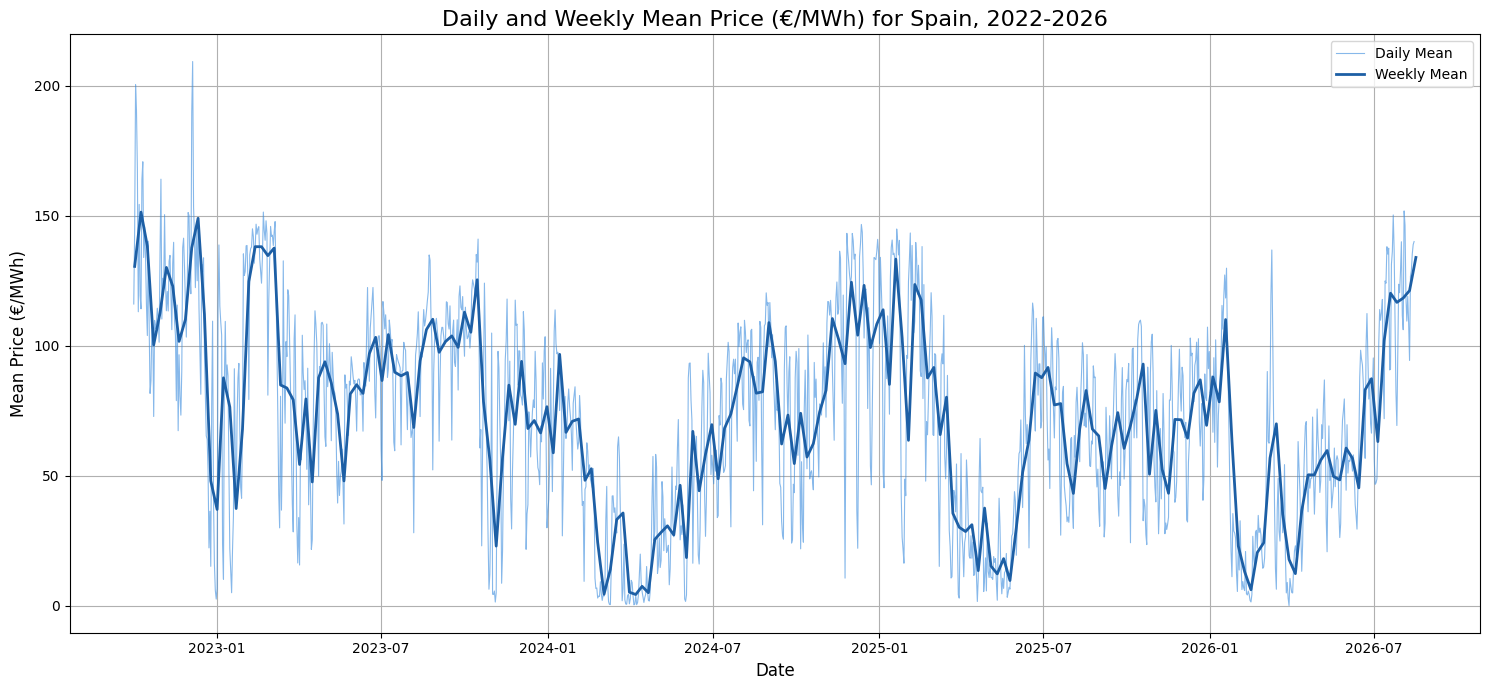

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

daily = df_full["price_eur_mwh"].resample("D").mean()
weekly = df_full["price_eur_mwh"].resample("W").mean()

plt.figure(figsize=(15, 7))

# Plot daily data with a lighter style
plt.plot(daily.index, daily.values, label='Daily Mean', color='#378ADD', alpha=0.6, linewidth=0.8)

# Plot weekly data with a stronger style
plt.plot(weekly.index, weekly.values, label='Weekly Mean', color='#1D5FA5', linewidth=2.0)

plt.title("Daily and Weekly Mean Price (€/MWh) for Spain, 2022-2026", fontsize = 16)
plt.xlabel("Date", fontsize = 12)
plt.ylabel("Mean Price (€/MWh)", fontsize = 12)
plt.grid()
plt.legend() # Add a legend to distinguish the lines
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()